Code for RPSMAP visualization

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from copy import deepcopy
from XACs.utils.utils import load_checkpoint
from XACs.utils.parsing import get_args
from XACs.utils.const import DATASETS
from XACs.dataset import MoleculeDataset
from torch_geometric.loader import DataLoader
import sys
plt.rcParams['pdf.fonttype'] = 'truetype'
#plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams["font.size"] = 15
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams.update({
    "pdf.use14corefonts": True
})
sys.argv = ['notebook']        
args = get_args() 

In [ ]:
def get_latent_representations(test_model, loader):
    model = deepcopy(test_model)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval().to(device)

    inputs = []
    def hook(module, input, output):
        inputs.append(input)

    model.mlp.register_forward_hook(hook)
    targets = []
    outs = []
    with torch.no_grad():
        for data in loader:
            x, edge_index = data.x.to(device), data.edge_index.type(torch.LongTensor).to(device)
            edge_attr = data.edge_attr.to(device)
            batch = data.batch.to(device)
            target = data.target.to(device)
            out = model(x, edge_attr, edge_index, batch)
            targets += target.cpu().numpy().tolist()
            outs += out.cpu().numpy().tolist()

    inputs = [i for sub in inputs for i in sub]
    inputs = torch.cat(inputs)
    inputs = inputs.cpu().numpy()
    #print("Number of samples: ", inputs.shape[0])
    #print("Number of features: ", inputs.shape[1])
    del model 
    return inputs, np.array(outs).reshape(-1, 1), np.array(targets).reshape(-1, 1)

def get_prop_dist_matrix(y: np.ndarray):
    assert y.shape[1]==1
    mat = np.abs(y - y.T)
    threshold = (1. - np.min(mat))/(np.max(mat) - np.min(mat))
    return (mat - np.min(mat)) / (np.max(mat) - np.min(mat)), threshold

def get_representation_sim_matrix(X: np.ndarray):
    # get the minmax normalized euclidean distance matrix
    dist = np.zeros((X.shape[0], X.shape[0]))
    ones = torch.ones(X.shape[0], X.shape[0])
    for i in range(X.shape[0]):
        for j in range(i+1, X.shape[0]):
            dist[i, j] = np.linalg.norm(X[i] - X[j])
    return ones - (dist - np.min(dist))/(np.max(dist) - np.min(dist))

def tanimoto_continuous(vec_a, vec_b):
    """
    Calculate Tanimoto similarity for continuous vectors.

    Args:
        vec_a (np.ndarray): First vector.
        vec_b (np.ndarray): Second vector.

    Returns:
        float: Tanimoto similarity between vec_a and vec_b.
    """
    dot_product = np.dot(vec_a, vec_b)
    magnitude_a_squared = np.sum(vec_a**2)
    magnitude_b_squared = np.sum(vec_b**2)
    return dot_product / (magnitude_a_squared + magnitude_b_squared - dot_product)

from rdkit import Chem
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

def get_fp(smiles):
    # Build a MorganGenerator to avoid deprecated AllChem.GetMorganFingerprintAsBitVect.
    fp_gen = GetMorganGenerator(radius=2, fpSize=1024)
    mol = Chem.MolFromSmiles(smiles)
    fp = fp_gen.GetFingerprintAsBitVect(mol)
    # Convert the bit-vector to an array
    arr = np.zeros((1, 1024))
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def cosine_similarity(a: torch.Tensor, b: torch.Tensor):
    assert a.shape[0] == b.shape[0] == 1
    return torch.nn.CosineSimilarity(dim=1)(a, b)

def RPSMap(dataset_name, model_orig, model, loader, sim_threshold = 0.90, metrics = 'both'):
    X_orig, pred_orig, y_orig = get_latent_representations(model_orig, loader)
    X, pred, y = get_latent_representations(model, loader)
    assert y.all()==y_orig.all()
    dist, threshold = get_prop_dist_matrix(y)
    # FPs
    smiles = [item for d in loader for item in d.smiles]
    fps = [get_fp(s) for s in smiles]
    if metrics == 'MinMaxEud':
        sim_fp = get_representation_sim_matrix(np.array(fps))
        sim_orig = get_representation_sim_matrix(X_orig)
        sim = get_representation_sim_matrix(X)
    elif metrics == 'cosinesim':
        sim_fp = np.zeros((len(fps), len(fps)))
        for i in range(len(fps)):
            for j in range(i+1, len(fps)):
                sim_fp[i, j] = cosine_similarity(torch.Tensor(fps[i]).unsqueeze(0), torch.Tensor(fps[j]).unsqueeze(0)).item()
        sim = np.zeros((X.shape[0], X.shape[0]))
        for i in range(X.shape[0]):
            for j in range(i+1, X.shape[0]):
                sim[i, j] = cosine_similarity(torch.Tensor(X[i]).unsqueeze(0), torch.Tensor(X[j]).unsqueeze(0)).item()
        
        sim_orig = np.zeros((X_orig.shape[0], X_orig.shape[0]))
        for i in range(X_orig.shape[0]):
            for j in range(i+1, X_orig.shape[0]):
                sim_orig[i, j] = cosine_similarity(torch.Tensor(X_orig[i]).unsqueeze(0), torch.Tensor(X_orig[j]).unsqueeze(0)).item()
    elif metrics == 'Tanimoto':
        sim_fp = np.zeros((len(fps), len(fps)))
        for i in range(len(fps)):
            for j in range(i+1, len(fps)):
                sim_fp[i, j] = tanimoto_continuous(fps[i], fps[j])
        sim = np.zeros((X.shape[0], X.shape[0]))
        for i in range(X.shape[0]):
            for j in range(i+1, X.shape[0]):
                sim[i, j] = tanimoto_continuous(X[i], X[j])
        sim_orig = np.zeros((X_orig.shape[0], X_orig.shape[0]))
        for i in range(X_orig.shape[0]):
            for j in range(i+1, X_orig.shape[0]):
                sim_orig[i, j] = tanimoto_continuous(X_orig[i], X_orig[j])
    else:
        sim_fp = get_representation_sim_matrix(np.array(fps))
        sim_orig = get_representation_sim_matrix(X_orig)
        sim = get_representation_sim_matrix(X)
        for i in range(len(fps)):
            for j in range(i+1, len(fps)):
                sim_fp[i, j] += cosine_similarity(torch.Tensor(fps[i]).unsqueeze(0), torch.Tensor(fps[j]).unsqueeze(0)).item()
                sim_fp[i, j] = sim_fp[i, j]*0.5
        for i in range(X.shape[0]):
            for j in range(i+1, X.shape[0]):
                sim[i, j] += cosine_similarity(torch.Tensor(X[i]).unsqueeze(0), torch.Tensor(X[j]).unsqueeze(0)).item()
                sim[i, j] = sim[i, j]*0.5
        for i in range(X_orig.shape[0]):
            for j in range(i+1, X_orig.shape[0]):
                sim_orig[i, j] += cosine_similarity(torch.Tensor(X_orig[i]).unsqueeze(0), torch.Tensor(X_orig[j]).unsqueeze(0)).item()
                sim_orig[i, j] = sim_orig[i, j]*0.5
    # write the upper triangle matrix of dist and sim to one pandas dataframe
    df = pd.DataFrame()
    df['sim'] = np.concatenate([sim_fp[np.triu_indices(sim_fp.shape[0], k=1)], sim_orig[np.triu_indices(sim_orig.shape[0], k=1)], sim[np.triu_indices(sim.shape[0], k=1)]])
    # add sim labeling to the dataframe, GNN for sim_orig, GNN+explain for sim
    df['label'] = np.concatenate([['ECFP']*sim_fp[np.triu_indices(sim_fp.shape[0], k=1)].shape[0], ['MPNN']*sim_orig[np.triu_indices(sim_orig.shape[0], k=1)].shape[0],['ACES-MPNN']*sim[np.triu_indices(sim.shape[0], k=1)].shape[0]])
    # double the dist to match the length of sim
    df['dist'] = np.concatenate([dist[np.triu_indices(dist.shape[0], k=1)], dist[np.triu_indices(dist.shape[0], k=1)], dist[np.triu_indices(dist.shape[0], k=1)]])
    df['dataset'] = [dataset_name]*df.shape[0]

    return df

Loading dataset CHEMBL2835_Ki from Data/CHEMBL2835_Ki/CHEMBL2835_Ki.csv


 56%|█████▌    | 343/615 [00:00<00:00, 447.96it/s]

100%|██████████| 615/615 [00:01<00:00, 428.90it/s]


Loaded Data/CHEMBL2835_Ki/mcs_dict_0.9.pkl
Found 60 cliffs in dataset CHEMBL2835_Ki
Loading model from results/results_cv_x/nn/CHEMBL2835_Ki/CHEMBL2835_Ki_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL2835_Ki/CHEMBL2835_Ki_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL2835_Ki/CHEMBL2835_Ki_cliff_811_42.csv


Text(0, 0.5, 'Property distance')

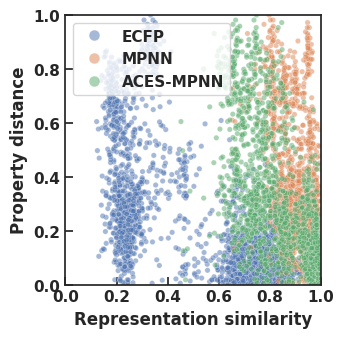

In [4]:
dataset = MoleculeDataset(args.dataset, args.data_dir)   
args.seed = 42
dataset.get_cliffs(args.sim_struct if args.sim_struct== 'mmp' else (args.sim_struct, args.sim_threshold), args.dist_threshold)
model = load_checkpoint(args, checkpoint_path=os.path.join('results/results_cv_x', args.conv_name, args.dataset, 
                                                f'{args.dataset}_MSE+direction_model_{args.seed}_rmse.pt'))  
model.eval()
model_orig = load_checkpoint(args, checkpoint_path=os.path.join('results/results_cv', args.conv_name, args.dataset, 
                                                f'{args.dataset}_MSE_model_{args.seed}_rmse.pt'))
model_orig.eval()
    
args.num_node_features=dataset.num_node_features
args.num_edge_features=dataset.num_edge_features 
data_train, data_val, data_test = dataset.split_data(split_ratio=args.split, 
                                                        split_method='cliff',
                                                        seed=args.seed, 
                                                        save_split=True)
#loader_train = DataLoader(data_train, batch_size=args.batch_size, shuffle=False)
#oader_val = DataLoader(data_val, batch_size=args.batch_size, shuffle=False)
loader_test = DataLoader(data_test, batch_size=len(data_test), shuffle=False)
X_orig, pred_orig, y_orig = get_latent_representations(model_orig, loader_test)
X, pred, y = get_latent_representations(model, loader_test)
sns.set_theme(rc={'figure.figsize':(3.3,3.5), "xtick.direction": "in","ytick.direction": "in", 'pdf.fonttype': 'truetype'}, style='ticks')
df = RPSMap(args.dataset, model_orig, model, loader_test, sim_threshold = 0.90, metrics='cosinesim')
#g = sns.relplot(data=df, x='sim', y='dist', hue='label', kind='scatter', alpha=0.5, legend=True, height=3, aspect=1.2)
g = sns.scatterplot(data=df, x='sim', y='dist', hue='label', s=15, alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
g.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
g.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.legend(markerscale=2)
#plt.plot([0, 1], [1, 0], '--', color='r')
#plt.axhline(y=0.2443, color='black', linestyle='--')
# plot a vertical line at the threshold of similarity
#plt.axvline(x=0.90, color='black', linestyle='--')
#plt.gca().set_aspect( adjustable='box')
plt.gca().set_aspect('auto', adjustable='box')

plt.xlabel('Representation similarity')
plt.ylabel('Property distance')
#plt.savefig(f"./RPSMap.pdf", format = "pdf", bbox_inches='tight')


Loading dataset CHEMBL4616_EC50 from Data/CHEMBL4616_EC50/CHEMBL4616_EC50.csv


100%|██████████| 682/682 [00:01<00:00, 385.14it/s]


Loaded Data/CHEMBL4616_EC50/mcs_dict_0.9.pkl
Found 355 cliffs in dataset CHEMBL4616_EC50
Loading model from results/results_cv_x/nn/CHEMBL4616_EC50/CHEMBL4616_EC50_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL4616_EC50/CHEMBL4616_EC50_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL4616_EC50/CHEMBL4616_EC50_cliff_811_42.csv
Loading dataset CHEMBL4792_Ki from Data/CHEMBL4792_Ki/CHEMBL4792_Ki.csv


100%|██████████| 1471/1471 [00:03<00:00, 448.12it/s]


Loaded Data/CHEMBL4792_Ki/mcs_dict_0.9.pkl
Found 794 cliffs in dataset CHEMBL4792_Ki
Loading model from results/results_cv_x/nn/CHEMBL4792_Ki/CHEMBL4792_Ki_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL4792_Ki/CHEMBL4792_Ki_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL4792_Ki/CHEMBL4792_Ki_cliff_811_42.csv
Loading dataset CHEMBL1871_Ki from Data/CHEMBL1871_Ki/CHEMBL1871_Ki.csv


...

Loaded Data/CHEMBL237_EC50/mcs_dict_0.9.pkl
Found 456 cliffs in dataset CHEMBL237_EC50
Loading model from results/results_cv_x/nn/CHEMBL237_EC50/CHEMBL237_EC50_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL237_EC50/CHEMBL237_EC50_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL237_EC50/CHEMBL237_EC50_cliff_811_42.csv
Loading dataset CHEMBL264_Ki from Data/CHEMBL264_Ki/CHEMBL264_Ki.csv


100%|██████████| 2862/2862 [00:04<00:00, 587.51it/s]


Loaded Data/CHEMBL264_Ki/mcs_dict_0.9.pkl
Found 1191 cliffs in dataset CHEMBL264_Ki
Loading model from results/results_cv_x/nn/CHEMBL264_Ki/CHEMBL264_Ki_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL264_Ki/CHEMBL264_Ki_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL264_Ki/CHEMBL264_Ki_cliff_811_42.csv
Loading dataset CHEMBL214_Ki from Data/CHEMBL214_Ki/CHEMBL214_Ki.csv


100%|██████████| 3317/3317 [00:06<00:00, 525.46it/s]


Loaded Data/CHEMBL214_Ki/mcs_dict_0.9.pkl
Found 1222 cliffs in dataset CHEMBL214_Ki
Loading model from results/results_cv_x/nn/CHEMBL214_Ki/CHEMBL214_Ki_MSE+direction_model_42_rmse.pt
Using linear embedding
Loading model from results/results_cv/nn/CHEMBL214_Ki/CHEMBL214_Ki_MSE_model_42_rmse.pt
Using linear embedding
Loading split from Data/CHEMBL214_Ki/CHEMBL214_Ki_cliff_811_42.csv


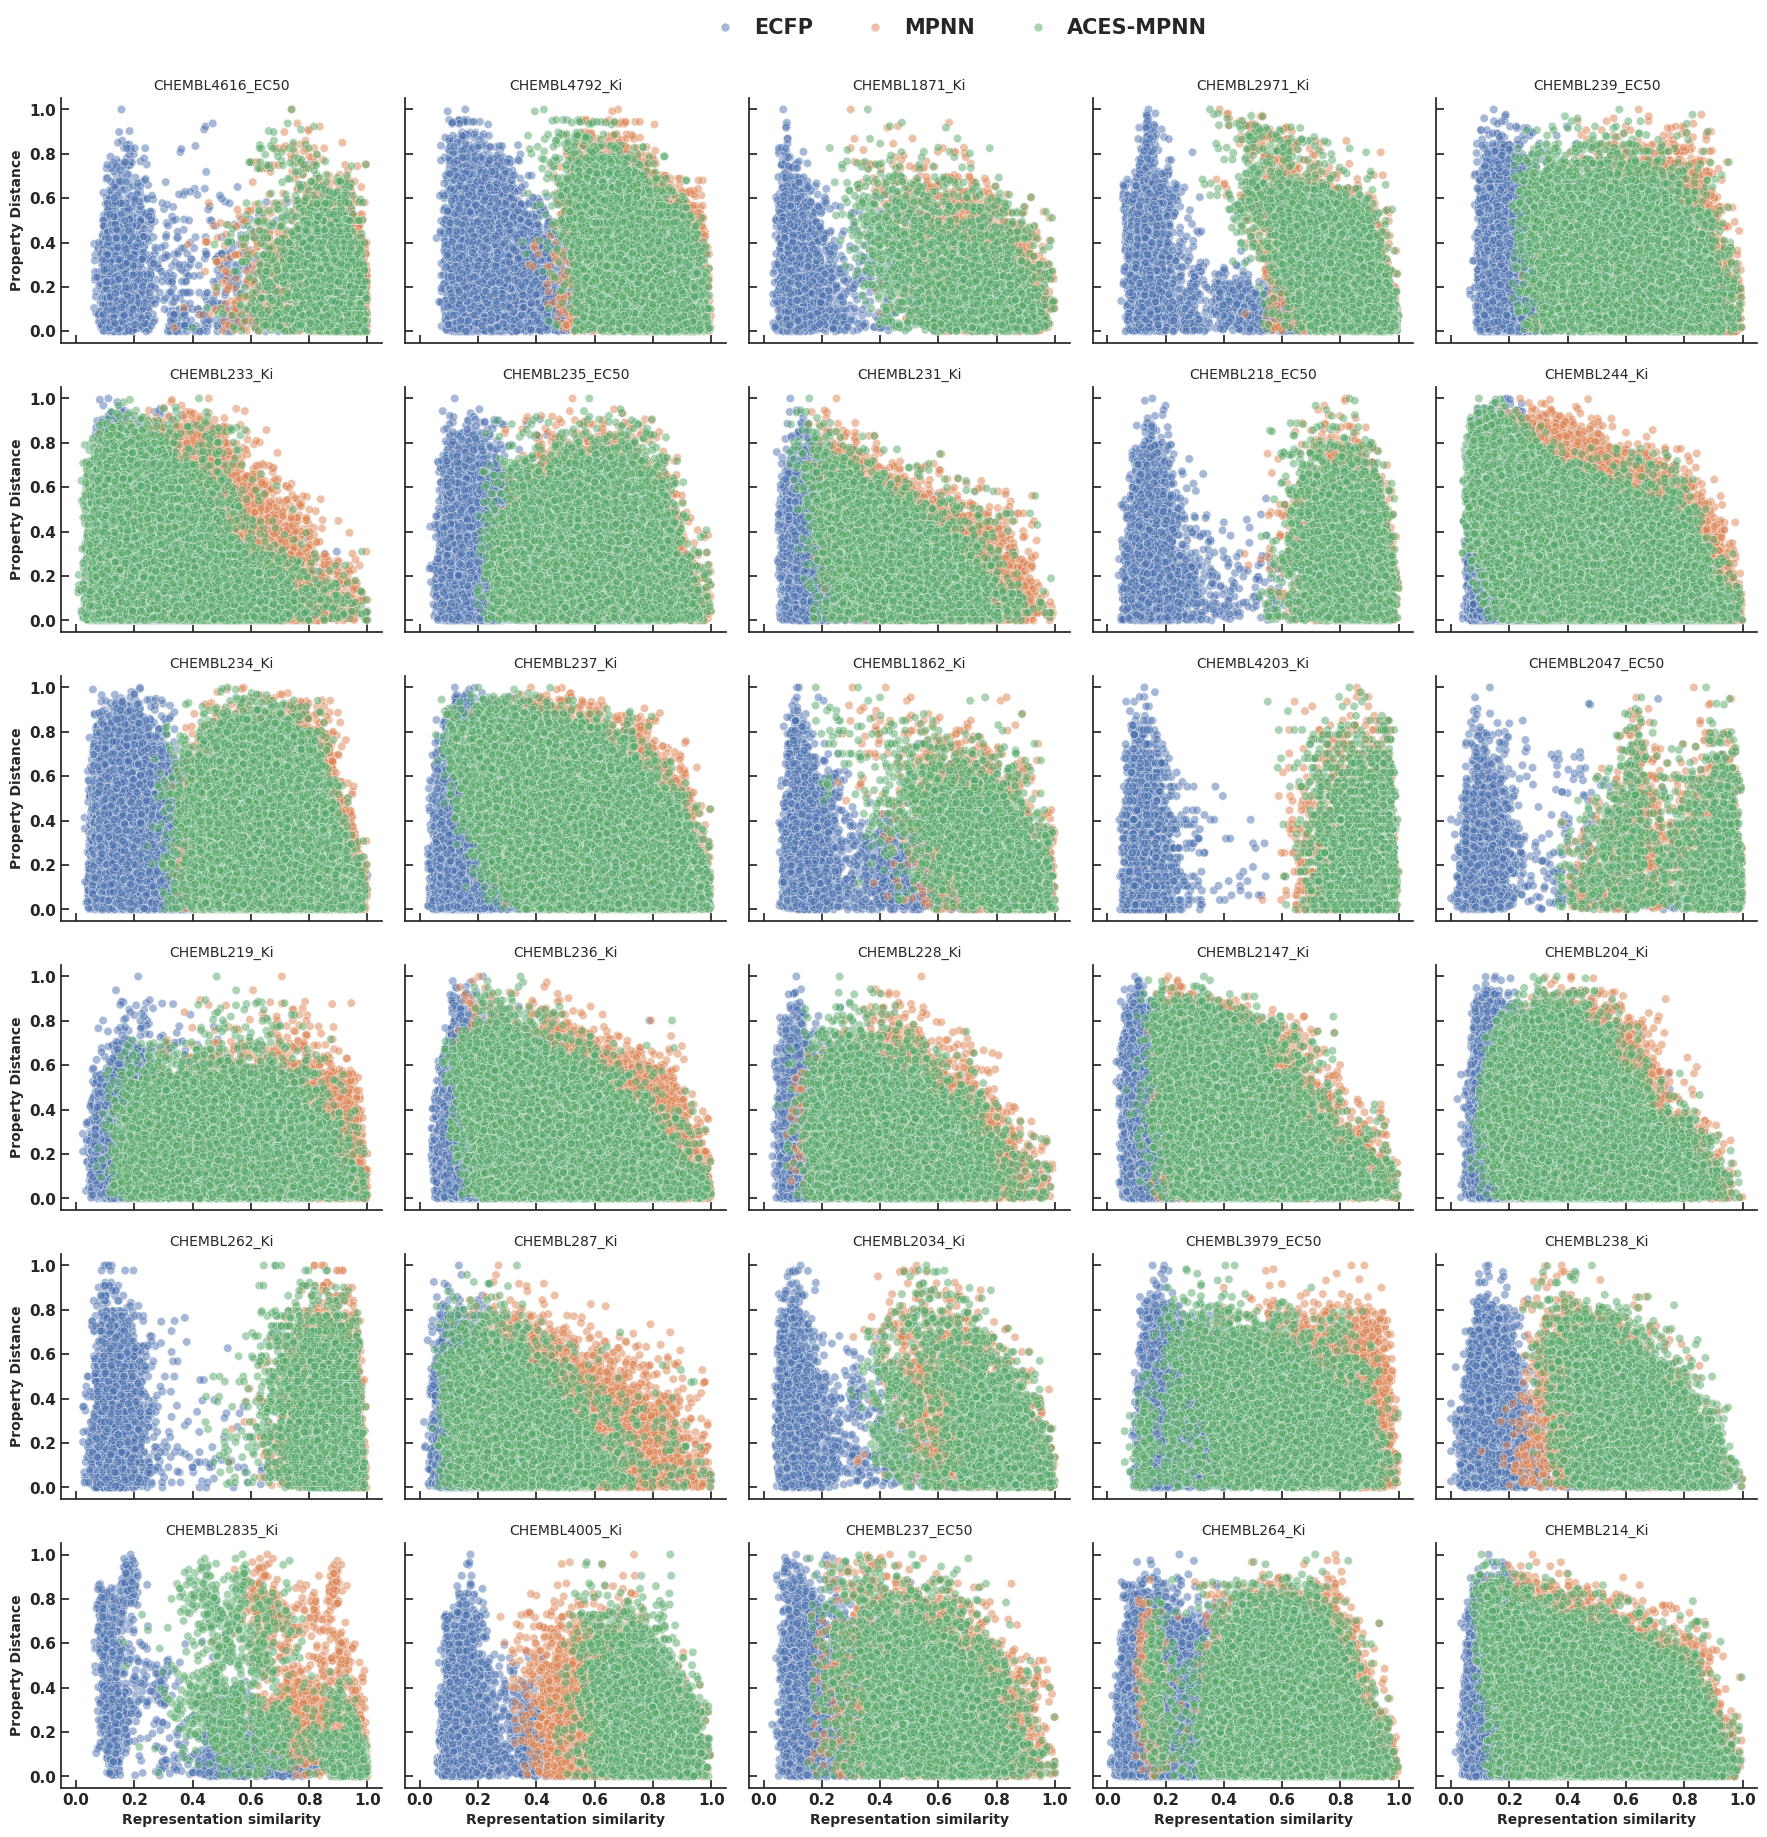

In [29]:
dfs = []
args.seed = 42
SIMILARITY_METRIC = 'Tanimoto' # ['MinMaxEud', 'cosinesim', 'Tanimoto']

for ds in DATASETS:
    args.dataset = ds
    dataset = MoleculeDataset(args.dataset, args.data_dir)   
    dataset.get_cliffs(args.sim_struct if args.sim_struct== 'mmp' else (args.sim_struct, args.sim_threshold), args.dist_threshold)
    model = load_checkpoint(args, checkpoint_path=os.path.join('results/results_cv_x', args.conv_name, args.dataset, 
                                                    f'{args.dataset}_MSE+direction_model_{args.seed}_rmse.pt'))  
    model.eval()
    model_orig = load_checkpoint(args, checkpoint_path=os.path.join('results/results_cv', args.conv_name, args.dataset, 
                                                    f'{args.dataset}_MSE_model_{args.seed}_rmse.pt'))           
    model_orig.eval()
    args.num_node_features=dataset.num_node_features
    args.num_edge_features=dataset.num_edge_features 
    data_train, data_val, data_test = dataset.split_data(split_ratio=args.split, 
                                                            split_method='cliff',
                                                            seed=args.seed, 
                                                            save_split=True)
    loader_test = DataLoader(data_test, batch_size=len(data_test), shuffle=False)
    #check_alignment(args, model, write_score)
    df = RPSMap(ds, model_orig, model, loader_test, sim_threshold = 0.90, metrics=SIMILARITY_METRIC)
    dfs += [df]
dfs = pd.concat(dfs, axis=0, ignore_index=True)
g = sns.relplot(data=dfs, col='dataset', x='sim', y='dist', hue='label', kind='scatter', alpha=0.5, legend=True, col_wrap=5, height=3, aspect=1.2)
axes = g.axes
g.set_titles("{col_name}", size=12)

for i, ax in enumerate(axes):
    ax.set_title(ax.get_title(), fontsize=10)
    ax.set_xlabel('Representation similarity', fontsize=10)
    ax.set_ylabel('Property Distance', fontsize=10)

handles, labels = g.axes[0].get_legend_handles_labels()
g._legend.remove()

# 2. add a new legend to the *figure*, not to any single axis
g.fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),    # little bit above the axes
    ncol=len(labels),              # all items in one row
    frameon=False,
    fontsize=15,                   # text size
    handletextpad=0.4)

g.figure.savefig(f'./images/RPSMap_{SIMILARITY_METRIC}.jpg', dpi=300, format='jpg', bbox_inches='tight')